# CTRSE — Clinical Triage & Risk Stratification Engine
## Notebook 1 of 2 — Data Understanding, EDA & Preprocessing
**Author:** Win Htet Aung (Jace) · Admin 243801J · IT3100 — AI Application Project

---

## Introduction — the problem we are solving

**Task.** Given only the information available *at the moment a patient arrives at an Emergency Department* — before any test is ordered or run — predict the **triage urgency level** the patient should be assigned. This is a **supervised, four-class classification** problem over the Singapore EPC scale:

| Level | Meaning | Clinical expectation |
|---|---|---|
| **P1** | Critical | Immediate, life-threatening — resuscitation |
| **P2** | Emergency | High-risk; assessment within minutes |
| **P3** | Urgent | Stable but time-sensitive |
| **P4** | Non-urgent | Routine; safe to redirect |

**Why it matters.** Triage is the first safety gate in an ED. Under-triaging a critical patient (calling a P1 a P3) can be fatal; over-triaging is merely inefficient. The cost of error is therefore **massively asymmetric**, and the whole project is engineered around that asymmetry rather than around raw accuracy.

**What makes it non-trivial.**
1. **Extreme class imbalance.** P1 is ~0.9% of arrivals (quantified in §3). A model that never predicts P1 still scores ~42% accuracy — so accuracy is the *wrong* objective and is replaced with imbalance-aware metrics in NB2.
2. **The label is a human judgement, not physiological ground truth.** The target is the triage nurse's **ESI** (Emergency Severity Index). The model therefore learns to **replicate the triage decision**, not to measure deterioration directly. A material share of high-acuity labels is **protocol-driven** (e.g. suicidal / intoxication / psychiatric complaints are triaged high by safety policy, not by vitals). This is stated openly throughout and carried as an explicit limitation — not a hidden assumption.
3. **Heavy, non-random missingness.** Key vitals (notably SpO₂) are 30–48% missing, and the missingness itself correlates with acuity. Naïve imputation would inject a constant that destroys signal and creates artefacts.

**What the model must get right.** Above all, **catch the rare P1 cases** (high Recall@P1) while keeping its mistakes in the *safe* direction — an error should land in a *more* urgent band, not a less urgent one. Overall accuracy is explicitly **not** the target.

### Label mapping (ESI → EPC)

| ESI | 1 | 2 | 3 | 4 | 5 |
|-----|---|---|---|---|---|
| **EPC** | P1 | P2 | P3 | P4 | P4 |

ESI 4 and 5 are both non-urgent and are merged into **P4** (§3 explains the reasoning and the limitation it carries). The mapping is an approximation — ESI is the US scale, EPC is Singapore's — and is treated as such.

### Notebook flow
1. **Column triage** — keep triage-time predictors, drop leakage columns *by rule*.
2. **Load & data-quality audit** — memory-frugal load and integrity checks.
3. **Target** — build P1–P4 from ESI.
4. **EDA** — one question: *what actually predicts acuity?* (answer: chief complaint, arrival mode, age — **not** vitals).
5. **Preprocessing** — leakage-safe split, train-only encoding, drop dead features, save artefacts.
6. **Hand-off** — manifest of artefacts for Notebook 2.


---

## What changed since Progress Review 1

The data understanding, EDA and preparation strategy were settled at PR1 and are unchanged. One correctness defect was found and fixed:

- **§5.3 — encoder fit order corrected.** The categorical encoder is now fitted only after the feature set is final, with an alignment assertion added in §5.4. This fixes a silent decode error and has **no effect on model performance** — see §5.3.

Everything else in this notebook stands as submitted at PR1.


## Data Collection

**Dataset.** A de-identified hospital **Emergency Department triage dataset** — ~560,000 ED visits described by **972 columns**, where every visit carries a triage-nurse-assigned **ESI** acuity score (1 = most acute … 5 = least). It is the triage-time subset of the dataset introduced by Hong, Haimovich & Taylor (2018) for predicting ED outcomes from information available at triage.

- **Source URL:** `<https://www.kaggle.com/datasets/maalona/hospital-triage-and-patient-history-data/data>`
- **Primary reference:** Hong WS, Haimovich AD, Taylor RA (2018). *Predicting hospital admission at emergency department triage using machine learning.* PLoS ONE 13(7): e0201016.
- **Local form:** 9 CSV parts (`converted_output_part01..09.csv`), loaded in §1–§2.

**Why this dataset, for this problem.** The task is to predict the *triage priority assigned at arrival*. That requires a dataset which (a) carries a **real triage-acuity label** on every record, and (b) records the **information genuinely available at triage** — not data generated later in the visit. This dataset satisfies both:

- Every visit has a **nurse-assigned ESI**, which is exactly the target the app must produce (mapped to P1–P4).
- It spans ~972 fields covering **chief complaints, presenting vitals, comorbidity / diagnosis history, home medications, demographics and mode of arrival** — i.e. the categories of information a patient or triage clerk can supply on arrival. This makes it directly transferable to the patient-facing app, where the same kinds of input are collected.
- At **~560k visits** it is large enough to learn a rare class (P1) and to support a clean train / validation / test discipline.

**The honest caveat (stated up front).** Because the label *is* the nurse's ESI, the model **replicates the triage decision** rather than measuring physiological ground truth. The data is also **single-site and adults-only** (no under-18 records — confirmed in EDA §4.3). These bound the claims that can be made and are carried as explicit limitations into NB2.

> The load code below reads **only the triage-time columns** (§1–§2), so leakage is excluded *before* any data enters memory.

### Setup

In [1]:
# Install dependencies (only these are required - no XGBoost/LightGBM/SMOTE/SHAP needed):
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import glob, gc, warnings, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110; pd.set_option("display.width",120)

# --- Reproducibility & shared constants (single source of truth) ---
RANDOM_STATE = 42
TEST_SIZE    = 0.20
ESI_TO_EPC       = {1:"P1", 2:"P2", 3:"P3", 4:"P4", 5:"P4"}
EPC_TO_MODEL_INT = {"P1":3, "P2":2, "P3":1, "P4":0}     # higher int = more urgent
EPC_ORDER  = ["P1","P2","P3","P4"]
EPC_COLORS = {"P1":"#d62728","P2":"#ff7f0e","P3":"#2ca02c","P4":"#1f77b4"}

print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("RANDOM_STATE =", RANDOM_STATE)

Python 3.9.25 | pandas 2.3.3 | numpy 1.26.4
RANDOM_STATE = 42


## 1 · Column triage — keep triage-time predictors, drop leakage

**This is the single most important data decision in the project.** The raw files have **972 columns**, but most describe things that happen *during* the visit — repeated vital/lab trends, lab results, test-order counts, and the final disposition. None of that exists at the moment of triage. Using any of it to predict the triage level would be **target leakage**: the model would look excellent in the notebook and then fail in the app, because those fields would be empty at prediction time.

So we classify every column **by rule** into *leakage* vs *triage-time predictor*, drop the leakage, and keep only what a clinician genuinely has at arrival. Doing this by rule rather than by hand-picking makes the decision **auditable and reproducible** — the breakdown below shows exactly how many columns each family contributes, and a later assertion (§2) confirms no leakage column survived the filter.

**Treated as leakage:** in-visit vital/lab *trends* (`*_last/_min/_max/_median`), in-visit test-order *counts* (`*_count`), lab *results* (`*_npos`), and the *outcome* (`disposition`).
**Kept as triage-time signal:** chief complaints (`cc_*`), comorbidity / diagnosis history, home medications (`meds_*`), demographics & arrival fields, presenting triage vitals (`triage_vital_*`), and utilisation history (`n_edvisits`, `n_admissions`, `n_surgeries`).

In [3]:
def classify(col):
    """Tag each raw column as leakage (measured/ordered during the visit, or the outcome) or a
    triage-time predictor family. Used both to drop leakage and to summarise what we keep."""
    c = col.lower()
    # ---- leakage: not known at triage ----
    if c.endswith(("_last","_min","_max","_median")):              return "LEAK · in-visit vital/lab trend"
    if c.endswith("_count") and c not in ("n_edvisits","n_admissions"): return "LEAK · in-visit test order"
    if c.endswith("_npos"):                                        return "LEAK · in-visit lab result"
    if c == "disposition":                                         return "LEAK · outcome"
    # ---- triage-time predictor families ----
    if c == "esi":                                                 return "TARGET (esi)"
    if c.startswith("triage_vital_"):                              return "vital sign"
    if c.startswith("cc_"):                                        return "chief complaint"
    if c.startswith("meds_"):                                      return "home medication"
    if c in ("n_edvisits","n_admissions","n_surgeries"):           return "utilisation history"
    if c in ("dep_name","gender","ethnicity","race","lang","religion","maritalstatus","employstatus",
             "insurance_status","arrivalmode","previousdispo","arrivalmonth","arrivalday",
             "arrivalhour_bin","age"):                             return "demographic / arrival"
    return "past-diagnosis history"

parts = sorted(glob.glob("converted_output_part*.csv"))
assert parts, "Place the converted_output_part*.csv files beside this notebook."
header = pd.read_csv(parts[0], nrows=0).columns.tolist()

families = Counter(classify(col) for col in header)
print(f"Found {len(parts)} data parts | {len(header)} raw columns\n")
print("Column families:")
for fam, n in sorted(families.items(), key=lambda kv: (-kv[1])):
    print(f"  {fam:32} {n:>4}")

KEEP     = [col for col in header if not classify(col).startswith("LEAK")]
KEEP_SET = set(KEEP)
n_leak   = len(header) - len(KEEP)
print(f"\n=> KEEP {len(KEEP)} triage-time columns (incl. target) · DROP {n_leak} leakage columns")

# Demographic/arrival fields that are stored as text -> treated as categorical later.
CATEGORICAL = [c for c in ["dep_name","gender","ethnicity","race","lang","religion","maritalstatus",
               "employstatus","insurance_status","arrivalmode","previousdispo",
               "arrivalmonth","arrivalday","arrivalhour_bin"] if c in KEEP_SET]
print("Categorical fields:", CATEGORICAL)

Found 9 data parts | 972 raw columns

Column families:
  LEAK · in-visit vital/lab trend   389
  past-diagnosis history            281
  chief complaint                   200
  home medication                    48
  LEAK · in-visit test order         18
  demographic / arrival              15
  LEAK · in-visit lab result          9
  vital sign                          7
  utilisation history                 3
  TARGET (esi)                        1
  LEAK · outcome                      1

=> KEEP 555 triage-time columns (incl. target) · DROP 417 leakage columns
Categorical fields: ['dep_name', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'arrivalmode', 'previousdispo', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin']


## 2 · Load the data (memory-frugal) & data-quality audit

We load **only the kept columns**, cast numeric fields to `float32` **while preserving `NaN`** (the downstream model reads missing values natively, so we never silently fill them here), and concatenate per part to keep peak memory low (~1.7 GB). We then audit integrity: rows with an invalid / missing ESI are dropped at load (they cannot be labelled), duplicates and the memory footprint are reported, and we **re-assert that no leakage column slipped through** the filter — a belt-and-suspenders check, because a single leaked column would invalidate every result that follows.

In [4]:
frames = []
for p in parts:
    d = pd.read_csv(p, usecols=lambda col: col in KEEP_SET, low_memory=False)
    d["esi"] = pd.to_numeric(d["esi"], errors="coerce")
    d = d[d["esi"].isin([1,2,3,4,5])]                         # keep only valid acuity labels
    numeric = [col for col in d.columns if col != "esi" and col not in CATEGORICAL]
    for col in numeric:
        d[col] = pd.to_numeric(d[col], errors="coerce").astype(np.float32)   # keep NaN; HGB handles it
    for col in CATEGORICAL:
        d[col] = d[col].astype("string")
    frames.append(d); del d; gc.collect()

df = pd.concat(frames, ignore_index=True); del frames; gc.collect()
print("Loaded:", df.shape)

Loaded: (558029, 555)


In [5]:
# ---- Data-quality audit ----
n_dupes = int(df.duplicated().sum())
mem_mb  = df.memory_usage(deep=True).sum() / 1e6
esi_na  = int(df["esi"].isna().sum())
print("Data-quality audit")
print(f"  rows x cols           : {df.shape[0]:,} x {df.shape[1]}")
print(f"  invalid/NaN ESI rows  : {esi_na} (already excluded at load)")
print(f"  exact duplicate rows  : {n_dupes:,}")
print(f"  in-memory footprint   : {mem_mb:,.0f} MB")
# Belt-and-suspenders: confirm no leakage column survived the column filter.
leaked = [c for c in df.columns if classify(c).startswith("LEAK")]
print(f"  leakage cols present  : {len(leaked)} (expected 0)")
assert not leaked, f"Leakage columns slipped through: {leaked[:5]}"

Data-quality audit
  rows x cols           : 558,029 x 555
  invalid/NaN ESI rows  : 0 (already excluded at load)
  exact duplicate rows  : 2
  in-memory footprint   : 1,716 MB
  leakage cols present  : 0 (expected 0)


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"  dropped {n_dupes} exact duplicate rows -> {len(df):,} rows remain")

  dropped 2 exact duplicate rows -> 558,027 rows remain


## 3 · Build the P1–P4 target

We map the nurse-assigned **ESI (1–5)** to the four-level **EPC** scale the app reports. Two design decisions, with their justification:

1. **Merge ESI 4 and 5 into P4.** Both are "non-urgent / safe to redirect"; the operational action is identical and ESI 5 is sparse. Collapsing them gives a cleaner, more learnable four-class problem without losing any decision-relevant distinction.
2. **Keep the mapping explicit and flagged as an approximation.** ESI is the US scale, EPC is Singapore's — clinically analogous but not identical. We therefore treat the label as *"the acuity tier the triage nurse assigned,"* not as exact EPC ground truth — an honest framing carried into the report.

The temperature column is stored in Fahrenheit and is converted to Celsius here. This is **cosmetic for the model** (a gradient-boosted tree is invariant to any monotonic transform of a feature) but makes the EDA plots and reported medians read correctly.

In [7]:
# Temperature is stored in Fahrenheit in this dataset; convert to Celsius for readable EDA.
# (Irrelevant to the tree model, which is invariant to monotonic transforms, but correct for plots.)
if "triage_vital_temp" in df.columns and df["triage_vital_temp"].median() > 50:
    f_med = df["triage_vital_temp"].median()
    df["triage_vital_temp"] = ((df["triage_vital_temp"] - 32) * 5/9).astype(np.float32)
    print(f"Temperature converted F->C (median {f_med:.0f}F -> {df['triage_vital_temp'].median():.1f}C)")

df["triage_level"] = df["esi"].astype(int).map(ESI_TO_EPC)
y = df["triage_level"].map(EPC_TO_MODEL_INT).astype(int)

counts = df["triage_level"].value_counts().reindex(EPC_ORDER)
summary = pd.DataFrame({"patients": counts, "share_%": (100*counts/counts.sum()).round(2)})
print(summary.to_string())
print(f"\nP1 (critical) prevalence: {100*counts['P1']/counts.sum():.1f}%  -> severe class imbalance (handled in NB2).")

Temperature converted F->C (median 98F -> 36.7C)
              patients  share_%
triage_level                   
P1                5271     0.94
P2              163532    29.31
P3              236229    42.33
P4              152995    27.42

P1 (critical) prevalence: 0.9%  -> severe class imbalance (handled in NB2).


## 4 · Exploratory Data Analysis

**The EDA is built around one question that directly shapes the model: _what actually predicts triage acuity?_** Rather than a scattershot of plots, the four analyses below tell one connected story:

1. **Imbalance** — establishes *why accuracy is the wrong metric* and motivates the entire NB2 evaluation strategy.
2. **Chief complaint** — the dominant signal, and the source of the "protocol-driven" caveat.
3. **Arrival mode & age** — strong, monotonic signals that are available at triage and need no measurement.
4. **Vitals** — the surprising finding that the "obvious" clinical inputs are *weak and heavily missing*, which reshapes the modelling approach.

Every insight is **printed from the computed values** (not hard-coded), so the narrative can never drift from what the data actually shows — a deliberate choice so the documentation stays defensible under questioning.

### 4.1 · Class imbalance — P1 is rare and cannot be ignored
If the critical class is a tiny fraction of arrivals, a model can post a high "accuracy" while catching *zero* P1 patients. This plot fixes the scale of that problem — and is the direct reason NB2 reports **Recall@P1** and **macro-F2** rather than accuracy, and handles imbalance with class weights plus a tunable P1 threshold.

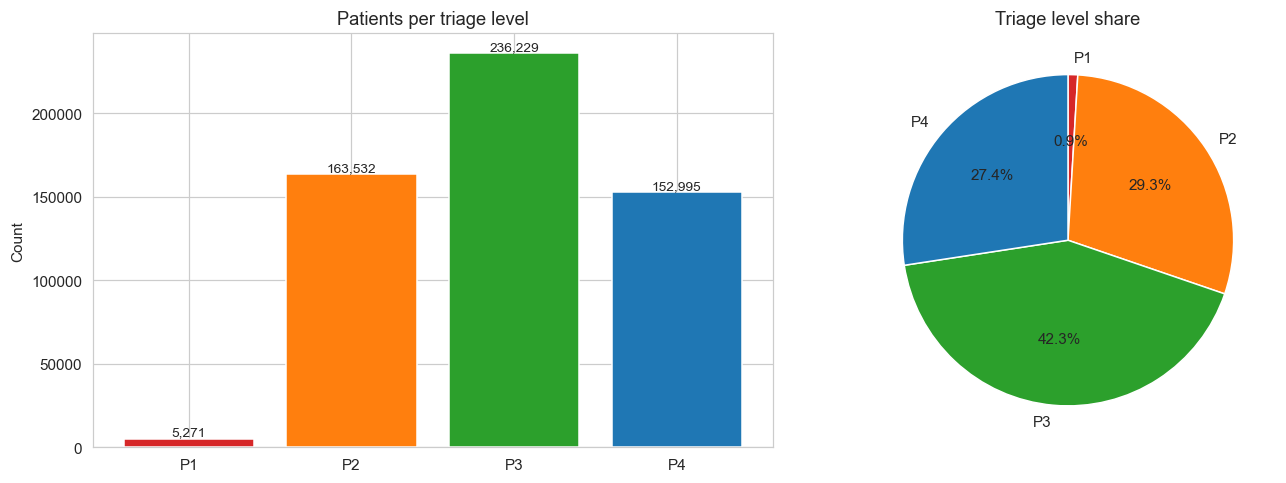

INSIGHT: P1 is only 0.9% of arrivals. Accuracy is therefore a misleading metric (predicting 'P3' for everyone scores ~42%). NB2 judges the model on Recall@P1 and macro-F2, and uses class weights + a tunable P1 threshold so the rare critical class is caught.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].bar(EPC_ORDER, counts.values, color=[EPC_COLORS[c] for c in EPC_ORDER])
for i,v in enumerate(counts.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax[0].set_title("Patients per triage level"); ax[0].set_ylabel("Count")
ax[1].pie(counts.values, labels=EPC_ORDER, colors=[EPC_COLORS[c] for c in EPC_ORDER],
          autopct="%1.1f%%", startangle=90, counterclock=False)
ax[1].set_title("Triage level share")
plt.tight_layout(); plt.savefig("eda_01_imbalance.png", bbox_inches="tight"); plt.show()
print(f"INSIGHT: P1 is only {100*counts['P1']/counts.sum():.1f}% of arrivals. Accuracy is therefore a misleading "
      f"metric (predicting 'P3' for everyone scores ~{100*counts['P3']/counts.sum():.0f}%). NB2 judges the model on "
      f"Recall@P1 and macro-F2, and uses class weights + a tunable P1 threshold so the rare critical class is caught.")

### 4.2 · Chief complaint is the strongest signal
Each `cc_*` flag is a presenting complaint recorded at triage. We rank complaints by their P1/P2 ("emergency") rate to see how strongly the *presenting reason* orders acuity — and to surface the complaints that are triaged high by **protocol** (suicidal, intoxication, psychiatric) rather than by physiology. That distinction is what makes "the model replicates triage, not deterioration" a concrete, evidenced claim rather than a disclaimer.

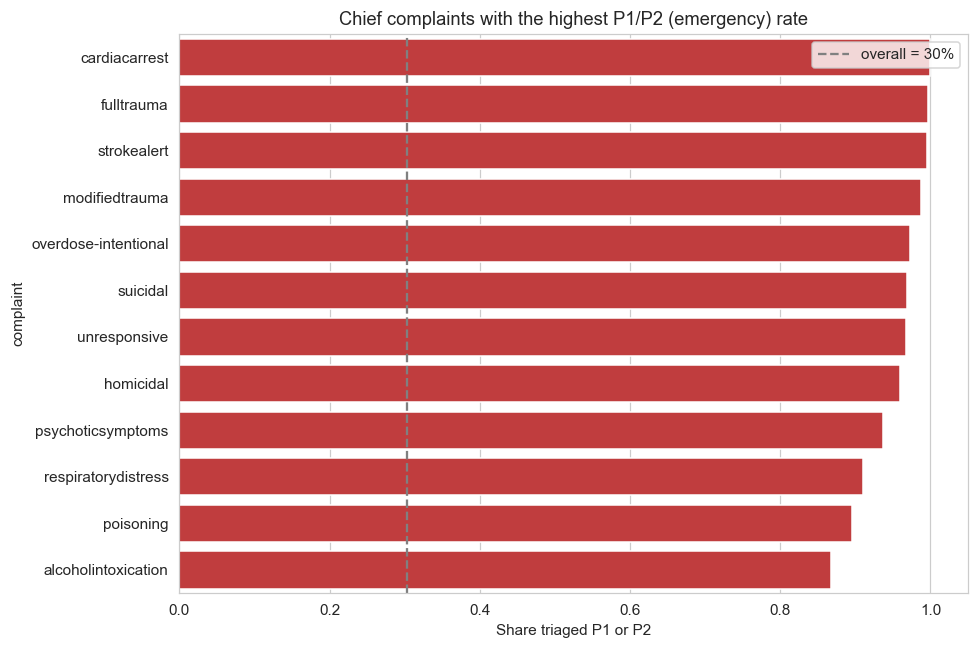

           complaint     n  emergency_rate
       cardiacarrest   458           100.0
          fulltrauma   662            99.7
         strokealert  2187            99.5
      modifiedtrauma  1327            98.7
overdose-intentional   615            97.2
            suicidal  8286            96.9
        unresponsive  1017            96.8
           homicidal   423            96.0
   psychoticsymptoms   486            93.6
 respiratorydistress   503            91.1
           poisoning  1125            89.6
 alcoholintoxication 15881            86.8

INSIGHT: presenting complaint orders acuity far more strongly than any vital. NOTE one important caveat: several of these (suicidal, alcohol intoxication, psychiatric) are triaged high by SAFETY/RESOURCE PROTOCOL, not physiological risk. The model partly learns these deterministic triage rules -- i.e. it replicates the triage decision rather than measuring clinical deterioration. State this in the report.


In [9]:
cc_cols = [c for c in df.columns if c.startswith("cc_")]
emerg   = df["triage_level"].isin(["P1","P2"]).values          # "emergency" = P1 or P2
rows = [(c[3:], int((df[c]==1).sum()), float(emerg[(df[c]==1).values].mean()))
        for c in cc_cols if (df[c]==1).sum() >= 300]
cc_rank = pd.DataFrame(rows, columns=["complaint","n","emergency_rate"]).sort_values("emergency_rate", ascending=False)
top = cc_rank.head(12)

plt.figure(figsize=(9,6))
sns.barplot(data=top, y="complaint", x="emergency_rate", color="#d62728")
plt.axvline(emerg.mean(), ls="--", color="grey", label=f"overall = {emerg.mean():.0%}")
plt.title("Chief complaints with the highest P1/P2 (emergency) rate"); plt.xlabel("Share triaged P1 or P2"); plt.legend()
plt.tight_layout(); plt.savefig("eda_02_chief_complaint.png", bbox_inches="tight"); plt.show()
print(top.assign(emergency_rate=(top.emergency_rate*100).round(1)).to_string(index=False))
print("\nINSIGHT: presenting complaint orders acuity far more strongly than any vital. NOTE one important "
      "caveat: several of these (suicidal, alcohol intoxication, psychiatric) are triaged high by SAFETY/RESOURCE "
      "PROTOCOL, not physiological risk. The model partly learns these deterministic triage rules -- i.e. it "
      "replicates the triage decision rather than measuring clinical deterioration. State this in the report.")

### 4.3 · Arrival mode and age are strong demographic signals
Both are known at triage and require no measurement. We check whether they track acuity **monotonically** — a clean, interpretable relationship is exactly the kind of signal a tree model exploits well, and both rank highly in the NB2 importance analysis. (This view also reveals the dataset is **adults-only**: the `<18` band is empty.)

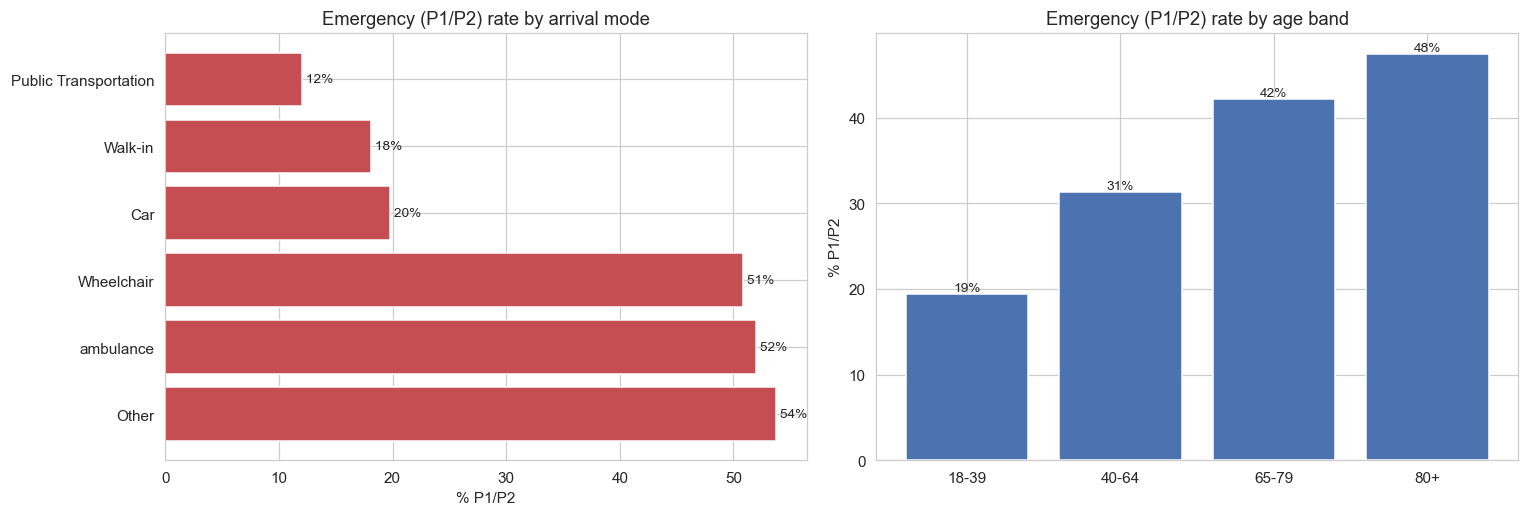

Arrival mode emergency rate (%):
arrivalmode
Other                    53.8
ambulance                52.0
Wheelchair               50.9
Car                      19.8
Walk-in                  18.1
Public Transportation    12.1

Age-band emergency rate (%):
band
18-39    19.5
40-64    31.3
65-79    42.2
80+      47.5

INSIGHT: arrival mode (ambulance/wheelchair vs walk-in) and age both track acuity strongly and monotonically -- both are available at triage and both rank highly in the NB2 importance analysis.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14,4.8))

# Arrival mode vs emergency rate
am = df.assign(e=emerg).groupby("arrivalmode")["e"].agg(["mean","size"])
am = am[am["size"] >= 500].sort_values("mean", ascending=False)
ax[0].barh(am.index.astype(str), am["mean"]*100, color="#C44E52")
for i,v in enumerate(am["mean"]*100): ax[0].text(v, i, f" {v:.0f}%", va="center", fontsize=9)
ax[0].set_title("Emergency (P1/P2) rate by arrival mode"); ax[0].set_xlabel("% P1/P2")

# Age band vs emergency rate
age = pd.to_numeric(df["age"], errors="coerce")
bands = pd.cut(age, bins=[0,18,40,65,80,200], labels=["<18","18-39","40-64","65-79","80+"], right=False)
ar = df.assign(e=emerg, band=bands).groupby("band")["e"].mean().dropna()*100
ax[1].bar(ar.index.astype(str), ar.values, color="#4C72B0")
for i,v in enumerate(ar.values): ax[1].text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
ax[1].set_title("Emergency (P1/P2) rate by age band"); ax[1].set_ylabel("% P1/P2")
plt.tight_layout(); plt.savefig("eda_03_arrival_age.png", bbox_inches="tight"); plt.show()

print("Arrival mode emergency rate (%):"); print((am["mean"]*100).round(1).to_string())
print("\nAge-band emergency rate (%):");   print(ar.round(1).to_string())
print("\nINSIGHT: arrival mode (ambulance/wheelchair vs walk-in) and age both track acuity strongly and "
      "monotonically -- both are available at triage and both rank highly in the NB2 importance analysis.")

### 4.4 · Vitals are weak and heavily missing
The intuitive assumption is that vital signs drive triage. This checks that assumption head-on: the **median P1-vs-P4 gap** per vital (how well it separates the extremes) against its **missing rate**. The result — small gaps, 30–48% missing — is what justifies keeping the full feature set instead of a vitals-first one, and not imputing the missing values.

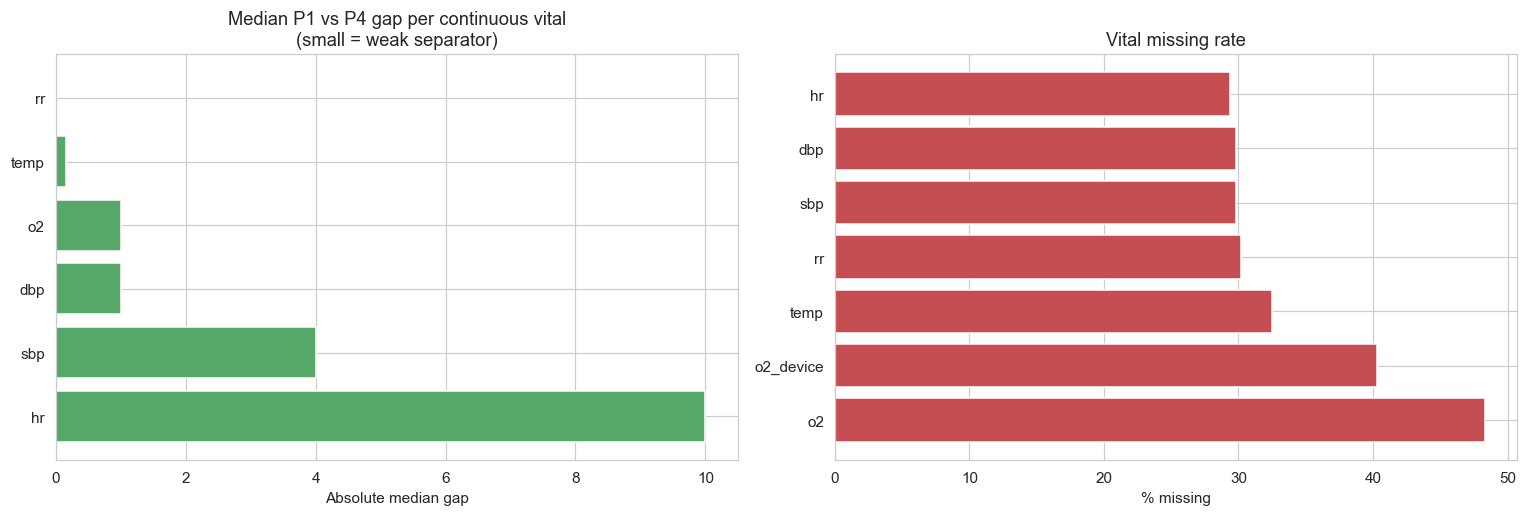

Median P1-vs-P4 gap per continuous vital:
 triage_vital_hr      10.00
triage_vital_sbp      4.00
triage_vital_dbp      1.00
triage_vital_o2       1.00
triage_vital_temp     0.17
triage_vital_rr       0.00

Missing rate per vital (%):
 triage_vital_o2           48.3
triage_vital_o2_device    40.3
triage_vital_temp         32.5
triage_vital_rr           30.2
triage_vital_sbp          29.8
triage_vital_dbp          29.8
triage_vital_hr           29.4

o2_device (categorical) value counts:
 triage_vital_o2_device
0.0    319572
NaN    224952
1.0     13503

INSIGHT: P1-vs-P4 median gaps are tiny and SpO2 is ~48% missing, so vitals ALONE are weak predictors. We keep them (the model uses them as minor signal) but do NOT impute -- a constant fill would erase what little signal exists. Caveat: vital missingness is itself acuity-correlated (low-acuity fast-track patients often skip full vitals), so part of the vital 'signal' is really missingness-as-proxy.


In [11]:
vitals = [c for c in df.columns if c.startswith("triage_vital_")]
# triage_vital_o2_device is CATEGORICAL (room air / nasal cannula / ...), not a continuous measurement,
# so a median "gap" is meaningless for it -- report it separately.
cont_vitals = [v for v in vitals if v != "triage_vital_o2_device"]
medians = df.groupby("triage_level")[cont_vitals].median().reindex(EPC_ORDER)
gap     = (medians.loc["P1"] - medians.loc["P4"]).abs().sort_values(ascending=False)
missing = (df[vitals].isna().mean()*100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14,4.8))
ax[0].barh(gap.index.str.replace("triage_vital_",""), gap.values, color="#55A868")
ax[0].set_title("Median P1 vs P4 gap per continuous vital\n(small = weak separator)"); ax[0].set_xlabel("Absolute median gap")
ax[1].barh(missing.index.str.replace("triage_vital_",""), missing.values, color="#C44E52")
ax[1].set_title("Vital missing rate"); ax[1].set_xlabel("% missing")
plt.tight_layout(); plt.savefig("eda_04_vitals.png", bbox_inches="tight"); plt.show()

print("Median P1-vs-P4 gap per continuous vital:\n", gap.round(2).to_string())
print("\nMissing rate per vital (%):\n", missing.to_string())
if "triage_vital_o2_device" in df.columns:
    print("\no2_device (categorical) value counts:\n",
          df["triage_vital_o2_device"].value_counts(dropna=False).head(6).to_string())
print("\nINSIGHT: P1-vs-P4 median gaps are tiny and SpO2 is ~48% missing, so vitals ALONE are weak predictors. "
      "We keep them (the model uses them as minor signal) but do NOT impute -- a constant fill would erase what "
      "little signal exists. Caveat: vital missingness is itself acuity-correlated (low-acuity fast-track patients "
      "often skip full vitals), so part of the vital 'signal' is really missingness-as-proxy.")

### 4.5 · EDA takeaways — and how each one shaped the model
- **Severe imbalance (P1 ≈ 0.9%)** → evaluate on **Recall@P1** and **macro-F2**, never accuracy; handle imbalance with class weights + a tunable P1 threshold (NB2).
- **Chief complaint dominates**, then **arrival mode** and **age**; **vitals are weak and 30–48% missing** → keep the *full* triage-time feature set rather than a hand-picked vitals-based one, which would have discarded the strongest signals.
- **Missing vitals are informative, not random** (low-acuity patients skip full vitals) → **do not impute**; let the model read `NaN` natively so the missingness pattern is preserved instead of erased.
- **A meaningful share of P1/P2 is protocol-driven** → frame the model as *replicating the triage decision*, not measuring physiology. This is the headline honesty point for the report.

## 5 · Preprocessing (leakage-safe by construction)

**Ordering is the whole game.** Every step is arranged so that **no information from the test set — or even the validation set — can influence training**. Concretely: we **split first**, then fit every transformer on the **training split only**.

1. **Stratified train/test split** on the 4-class label, *before any fitting*. Stratification keeps the 0.9% P1 prevalence identical across splits (verified in the output), so the test set stays a faithful sample of reality.
2. **Drop features that are constant in the *training* set.** A single-valued column carries zero information and can only add noise. "Constant" is judged on **train alone** (not the full data) so we never peek at the test set.
3. **Encode categoricals with a train-fitted `OrdinalEncoder`.** Ordinal rather than one-hot, because the tree model splits on thresholds and does not assume the integers are ordered — so 14 text fields become 14 compact integer columns instead of hundreds of one-hot columns. Unknown / missing categories map to `NaN`, which the model treats as "missing," so an unseen category at app-time **degrades gracefully** instead of crashing.

**What we deliberately do NOT do — and why:**
- **No imputation.** SpO₂ is ~48% missing; a constant fill would destroy its variance and (in earlier drafts) created a "missingness-flag dominates importance" artefact. `HistGradientBoosting` reads `NaN` natively, so imputation is unnecessary *and* harmful here.
- **No SMOTE.** The feature space is overwhelmingly **binary** (complaints, meds, history). Interpolating between binary rows fabricates impossible fractional "patients," and stacking SMOTE on top of class weights would *double-correct* the imbalance. Imbalance is handled with `class_weight="balanced"` in NB2 instead.
- **No scaling.** Gradient-boosted trees are invariant to monotonic feature transforms, so standardisation would add a step and change nothing.
- **No missingness flags.** The model already uses `NaN` as signal, so explicit flags were redundant.

In [12]:
# --- 5.1 Stratified split (before any fitting) ---
feature_cols_all = [c for c in df.columns if c not in ("esi","triage_level")]
X = df[feature_cols_all]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE,
                                          random_state=RANDOM_STATE, stratify=y)
print(f"Train: {len(X_tr):,}  Test: {len(X_te):,}")

# Confirm the stratified split preserved class proportions (sanity check).
print("\nClass proportions (train vs test) — should match:")
for lvl, code_int in EPC_TO_MODEL_INT.items():
    print(f"  {lvl}: train {np.mean(y_tr==code_int):.4f}  test {np.mean(y_te==code_int):.4f}")

Train: 446,421  Test: 111,606

Class proportions (train vs test) — should match:
  P1: train 0.0094  test 0.0094
  P2: train 0.2931  test 0.2931
  P3: train 0.4233  test 0.4233
  P4: train 0.2742  test 0.2742


In [13]:
# --- 5.2 Drop features that are constant in the TRAINING set (carry zero information) ---
nunq = X_tr.nunique(dropna=True)
dead_cols = nunq[nunq <= 1].index.tolist()
feature_cols = [c for c in feature_cols_all if c not in dead_cols]
X_tr = X_tr[feature_cols].copy(); X_te = X_te[feature_cols].copy()
CATEGORICAL_USED = [c for c in CATEGORICAL if c in feature_cols]
print(f"Dropped {len(dead_cols)} constant-in-train features (e.g. {dead_cols[:5]})")
print(f"Remaining features: {len(feature_cols)}")

Dropped 1 constant-in-train features (e.g. ['ecodesmachinery'])
Remaining features: 553


### 5.3 · Encoding — the defect corrected since PR1

**The defect.** The encoder was fitted while the categorical list still held a column that was later excluded from the saved feature set, so the saved encoder carried one more category list than the saved `categorical_cols`. Because that column sat first in the ordering, every categorical after it decoded **one position out**: `arrival_mode` codes were resolved against the insurance category list, producing values such as `arrival_mode: "Medicaid"`.


**Why it went unnoticed at PR1 and the fix.** Nothing caught it, because no exception was raised and no metric moved. The encoded arrays were correct and training was unaffected; only the decode path was wrong, and that is the path the explanation layer reads. The fix is to finalise the feature set before fitting. The assertion in §5.4 would have caught the original mismatch (14 category lists against 13 names) and now runs on every execution.


In [14]:
# --- 5.3 Encode categoricals (fit on TRAIN only; unknown & missing -> NaN) ---
# Drop dep_name BEFORE fitting the encoder (not at save time). dep_name is an
# anonymised site code (A/B/C) with no transferable signal; the ORDERING reason is
# the important one: if it is dropped only after the fit, the saved encoder keeps a
# category-list entry for it while categorical_cols.pkl does not -> in NB3 every
# categorical after dep_name decodes to the WRONG field (e.g. arrival_mode -> an
# insurance value). Dropping it here keeps enc.categories_ positionally aligned with
# the saved categorical_cols.
X_tr = X_tr.drop(columns="dep_name", errors="ignore")
X_te = X_te.drop(columns="dep_name", errors="ignore")
feature_cols = [c for c in feature_cols if c != "dep_name"]
CATEGORICAL_USED = [c for c in CATEGORICAL_USED if c != "dep_name"]

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan, encoded_missing_value=np.nan)
X_tr[CATEGORICAL_USED] = enc.fit_transform(X_tr[CATEGORICAL_USED].astype(str))
X_te[CATEGORICAL_USED] = enc.transform(X_te[CATEGORICAL_USED].astype(str))
X_tr = X_tr.astype(np.float32); X_te = X_te.astype(np.float32)
print(f"Encoded {len(CATEGORICAL_USED)} categorical fields (train-fit). Feature matrix: {X_tr.shape[1]} columns")

# --- 5.4 Integrity checks before saving ---
assert list(X_tr.columns) == list(X_te.columns) == feature_cols, "feature alignment mismatch"
assert X_tr.shape[1] == len(feature_cols)
# Encoder<->columns alignment guard: exactly one category list per saved categorical
# column, same order. This is the invariant NB3's decoder relies on; asserting it here
# makes the arrival_mode-decodes-to-insurance drift impossible to ship silently.
assert len(enc.categories_) == len(CATEGORICAL_USED), \
    f"encoder/categorical_cols length mismatch: {len(enc.categories_)} vs {len(CATEGORICAL_USED)}"
print("Integrity checks passed: train/test share identical ordered columns; encoder aligned to categoricals.")

Encoded 13 categorical fields (train-fit). Feature matrix: 552 columns
Integrity checks passed: train/test share identical ordered columns; encoder aligned to categoricals.


In [15]:
# --- 5.5 Save artefacts for Notebook 2 ---
# dep_name was already dropped in 5.3 (before the encoder fit), so the encoder and
# categorical_cols.pkl are positionally aligned -- nothing to drop here.
np.save("X_train.npy", X_tr.values); np.save("X_test.npy", X_te.values)
np.save("y_train.npy", y_tr.values); np.save("y_test.npy", y_te.values)   # P1-P4 ints (P1=3 .. P4=0)
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(CATEGORICAL_USED, "categorical_cols.pkl")
joblib.dump(enc, "ordinal_encoder.pkl")
joblib.dump(EPC_TO_MODEL_INT, "epc_map.pkl")

manifest = pd.DataFrame([
    ["X_train.npy", f"{X_tr.shape}", "training features (float32, NaN preserved)"],
    ["X_test.npy",  f"{X_te.shape}", "test features"],
    ["y_train.npy", f"{y_tr.shape}", "training labels (P1=3..P4=0)"],
    ["y_test.npy",  f"{y_te.shape}", "test labels"],
    ["feature_cols.pkl", f"{len(feature_cols)} names", "feature order"],
    ["categorical_cols.pkl", f"{len(CATEGORICAL_USED)} names", "categorical fields"],
    ["ordinal_encoder.pkl", "fitted", "train-fitted categorical encoder"],
    ["epc_map.pkl", "dict", "EPC -> model-int mapping"],
], columns=["artefact","shape/size","description"])
print("Saved artefacts:\n"); print(manifest.to_string(index=False))

Saved artefacts:

            artefact    shape/size                                description
         X_train.npy (446421, 552) training features (float32, NaN preserved)
          X_test.npy (111606, 552)                              test features
         y_train.npy     (446421,)               training labels (P1=3..P4=0)
          y_test.npy     (111606,)                                test labels
    feature_cols.pkl     552 names                              feature order
categorical_cols.pkl      13 names                         categorical fields
 ordinal_encoder.pkl        fitted           train-fitted categorical encoder
         epc_map.pkl          dict                   EPC -> model-int mapping


## 6 · Summary & hand-off to Notebook 2

**What this notebook established**
- **Leakage controlled by rule:** kept **555 triage-time columns**, dropped **417 leakage columns**, and asserted none survived. (After the split, constant-in-train and non-transferable site-code columns are removed → **552 model features**.)
- **Data quality verified:** ~558k labelled visits, no invalid labels, negligible duplicates, ~1.7 GB handled memory-frugally.
- **Target built:** P1–P4 from ESI, with the **0.9% P1 imbalance** quantified — the fact that governs every metric choice in NB2.
- **EDA finding that reshaped the model:** acuity is driven by **chief complaint, arrival mode and age**, while **vitals are weak and 30–48% missing**, and part of the signal is **protocol-driven**. This justified keeping the full feature set, reading `NaN` natively, and evaluating on Recall@P1 / macro-F2.
- **Leakage-safe preprocessing:** split-first, train-only encoding, dead-feature removal, `NaN` preserved, no impute / SMOTE / scale.

**Note on the two feature counts** (so they are never confused): **555** = triage-time *columns kept*, which *includes* the `esi` target. After removing the target and the derived `triage_level`, and dropping the constant-in-train and site-code columns, the model trains on **552 features**.

**Artefacts saved for Notebook 2:** `X_train/X_test/y_train/y_test.npy`, `feature_cols.pkl`, `categorical_cols.pkl`, `ordinal_encoder.pkl`, `epc_map.pkl` — with `NaN` preserved in the arrays.

**Notebook 2 will:** train a class-weighted `HistGradientBoostingClassifier`, tune it against a held-out validation split on **macro-F2**, evaluate on **Recall@P1 / macro-F2 / balanced accuracy** against trivial baselines, calibrate a **tunable P1 threshold** with an explicit operating-point table, and produce a permutation-importance analysis plus a per-patient explanation payload for the Gen-AI layer.


---
